# Comparaison des modes SQL — Assistant RAG NBA (Projet 10)

## Objectif et questions d'évaluation

Ce notebook mesure **l'évolution** de l'assistant au fil de l'ajout d'un accès SQL :

> **RAG seul → RAG + SQL contrôlé → hybride enrichi → LLM→SQL**

Il répond à **deux questions d'évaluation** :

1. **L'ajout d'un accès SQL améliore-t-il l'assistant RAG seul ?** *(Partie A)*
2. **Une fois le SQL ajouté, quel mode retenir** — SQL contrôlé, hybride enrichi ou
   LLM→SQL ? *(Partie B)*

**Lecture importante :** les scores **globaux** ne sont qu'un repère. Le jeu figé contient
peu de questions chiffrées, donc les conclusions se lisent **par route et par type de
question**, pas seulement en moyenne globale.

> Ce notebook **ne relance aucun appel API** : il lit uniquement les fichiers déjà produits
> dans `evaluation/results/`. Si un fichier manque, un message clair l'indique.

## Conditions comparées

| condition | description |
|---|---|
| **`baseline_rag`** | RAG texte seul (l'« avant », sans routage SQL) — point de référence. |
| **`controlled_sql`** | Routage SQL **contrôlé** : requêtes figées, colonnes sur liste blanche. |
| **`controlled_hybrid`** | SQL contrôlé **+ contexte RAG** pour les questions hybrides (mixte texte/chiffres). |
| **`llm_sql`** | SQL **généré par le LLM**, puis **validé** (lecture seule) et **exécuté par le SQL Tool sécurisé**. |

> **Sécurité (cadrage du projet) :** en mode `llm_sql`, le LLM ne fait que **proposer** la
> requête ; il ne l'exécute **jamais**. Toute requête passe par le SQL Tool en
> **lecture seule** (`SQLite mode=ro`, `SELECT`/`WITH` uniquement, une seule instruction).
>
> `baseline_rag_no_logfire` est la **variante prototype** de la baseline (sans traçage
> Logfire) ; on la garde en repère, affichée en premier.

### Chargement des résultats *(aucun appel API)*

In [1]:
import os
import sys

# Se placer à la racine du repo (le notebook vit dans notebooks/) pour les chemins relatifs.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 90)

from utils.results_io import (
    results_path, file_status, load_summary, load_summaries, load_results_csv,
    global_scores_table, route_scores_table, diff_table, METRICS,
    category_scores_table, metric_by_category_table, available_categories,
    route_scores_multi_table,
    load_variance_runs, variance_meanstd_display, variance_mean_table,
    variance_std_table, variance_category_means,
)

# Conditions « routées » (SQL/hybride/LLM), avec détail PAR ROUTE.
SUMMARY_PATHS = {
    "controlled_sql": results_path("ragas_routed_controlled_sql_only_summary.json"),
    "controlled_hybrid": results_path("ragas_routed_controlled_sql_with_rag_context_summary.json"),
    "llm_sql": results_path("ragas_routed_llm_sql_only_summary.json"),
}
# Baselines RAG seul (« avant » le routage SQL) : scores GLOBAUX uniquement (pas de routes).
BASELINE_PATHS = {
    "baseline_rag_no_logfire": results_path("ragas_baseline_summary.no_logfire.json"),
    "baseline_rag": results_path("ragas_baseline_summary.json"),
}
for label, path in {**BASELINE_PATHS, **SUMMARY_PATHS}.items():
    print(f"{label:24} {file_status(path)}")

baseline_rag_no_logfire  OK — evaluation/results/ragas_baseline_summary.no_logfire.json
baseline_rag             OK — evaluation/results/ragas_baseline_summary.json
controlled_sql           OK — evaluation/results/ragas_routed_controlled_sql_only_summary.json
controlled_hybrid        OK — evaluation/results/ragas_routed_controlled_sql_with_rag_context_summary.json
llm_sql                  OK — evaluation/results/ragas_routed_llm_sql_only_summary.json


In [2]:
summaries, missing = load_summaries(SUMMARY_PATHS)
baselines, missing_baselines = load_summaries(BASELINE_PATHS)

# Pour la vue GLOBALE on combine baselines (RAG seul) + conditions routées.
# L'ordre place les baselines « avant » en tête, puis les modes routés « après ».
GLOBAL_SUMMARIES = {**baselines, **summaries}

if missing or missing_baselines:
    print("Conditions ABSENTES (relancer le run correspondant) :", missing + missing_baselines)
    print("Commande type : poetry run python scripts/evaluate_ragas.py --eval-mode routed")
    print("Baseline RAG  : poetry run python scripts/evaluate_ragas.py --eval-mode baseline_rag")
print("Conditions routées :", list(summaries.keys()))
print("Baselines RAG seul :", list(baselines.keys()))

Conditions routées : ['controlled_sql', 'controlled_hybrid', 'llm_sql']
Baselines RAG seul : ['baseline_rag_no_logfire', 'baseline_rag']


## Composition du jeu figé E01–E15

Le jeu d'évaluation **figé E01–E15** est le jeu officiel de comparaison du projet. On regarde
sa composition par **type de question** et par **route** (calculée par le routeur).

> ⚠️ **Le jeu figé contient peu de questions SQL** (6 sur 15). Les scores **globaux** doivent
> donc être **complétés par des analyses par route et par type de question** — c'est le fil
> directeur de tout le notebook.

Jeu figé : 15 questions


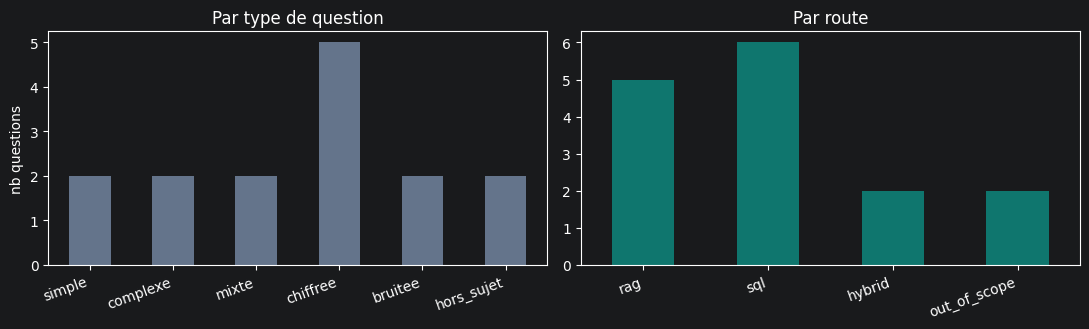

,par type,par route
bruitee,2.0,
chiffree,5.0,
complexe,2.0,
hors_sujet,2.0,
hybrid,,2.0
mixte,2.0,
out_of_scope,,2.0
rag,,5.0
simple,2.0,
sql,,6.0


Seules 6 questions passent par la route « sql » -> la comparaison SQL ne porte que
sur une petite part du jeu figé : on complète par route et par type ci-dessous.


In [3]:
# Type de question : depuis le jeu figé ; route : depuis un run routé (le routeur l'assigne).
frozen = load_results_csv("evaluation/evaluation_questions.csv")
routed_csv = load_results_csv(results_path("ragas_routed_controlled_sql_only_results.csv"))

if frozen is None or routed_csv is None:
    print("Jeu figé ou run routé absent :")
    print("  ", file_status("evaluation/evaluation_questions.csv"))
    print("  ", file_status(results_path("ragas_routed_controlled_sql_only_results.csv")))
else:
    by_cat = frozen["category"].value_counts().rename("nb_questions")
    by_route = routed_csv["route"].value_counts().rename("nb_questions")

    print(f"Jeu figé : {len(frozen)} questions")
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    by_cat.reindex(["simple", "complexe", "mixte", "chiffree", "bruitee", "hors_sujet"]).dropna().plot(
        kind="bar", ax=axes[0], color="#64748b")
    axes[0].set_title("Par type de question")
    axes[0].set_ylabel("nb questions")
    by_route.reindex(["rag", "sql", "hybrid", "out_of_scope"]).dropna().plot(
        kind="bar", ax=axes[1], color="#0f766e")
    axes[1].set_title("Par route")
    for ax in axes:
        ax.set_xlabel("")
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    combo = pd.DataFrame({"par type": by_cat, "par route": by_route})
    display(combo.fillna("").astype(object))
    print("Seules 6 questions passent par la route « sql » -> la comparaison SQL ne porte que")
    print("sur une petite part du jeu figé : on complète par route et par type ci-dessous.")

---
# Partie A — Le SQL améliore-t-il le RAG seul ?

## Scores globaux : RAG seul vs modes routés

Premier repère : les scores **moyens globaux** des conditions (les 2 baselines RAG seul, puis
les modes routés). **À ne lire que comme un repère** — la conclusion vient des analyses par
type et par route (Partie B).

,baseline_rag_no_logfire,baseline_rag,controlled_sql,controlled_hybrid,llm_sql
faithfulness,0.184,0.353,0.496,0.534,0.556
answer_relevancy,0.614,0.552,0.614,0.604,0.559
context_precision,0.438,0.362,0.569,0.502,0.619
context_recall,0.467,0.433,0.611,0.611,0.611


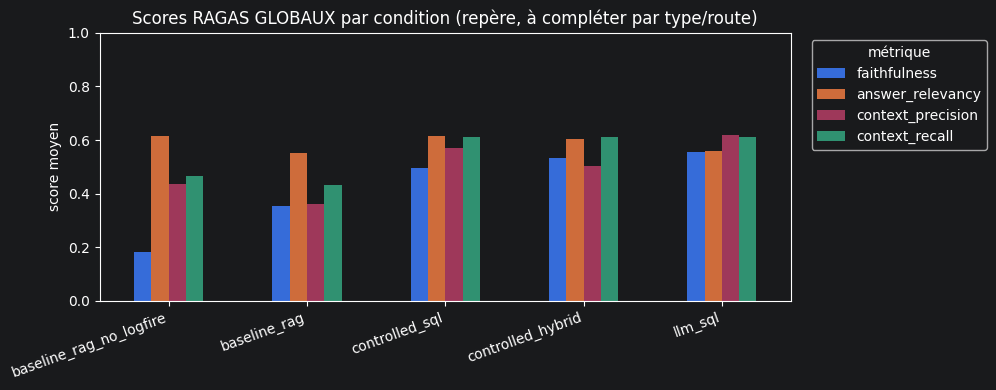

In [4]:
if not GLOBAL_SUMMARIES:
    print("Aucun résumé chargé.")
else:
    glob = global_scores_table(GLOBAL_SUMMARIES)
    display(glob.round(3))

    ax = glob.T.plot(kind="bar", figsize=(10, 4))
    ax.set_title("Scores RAGAS GLOBAUX par condition (repère, à compléter par type/route)")
    ax.set_ylabel("score moyen")
    ax.set_ylim(0, 1)
    ax.legend(title="métrique", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## Gains vs baseline RAG, par type de question

Comparaison **plus équitable** que le global : pour chaque type de question, on calcule le
**gain de chaque mode routé par rapport au RAG seul** :

> **gain = score(mode) − score(`baseline_rag`)**

**Heatmap divergente** : 🟩 vert = le SQL **améliore**, 🟥 rouge = le SQL **dégrade**, jaune =
neutre. Les **modes routés sont moyennés sur 5 runs** (robuste au bruit du juge) ; la
référence `baseline_rag` est sur 1 run. Le type **`hors_sujet` est exclu** (traité à part plus bas, c'est un refus).

On s'attend à voir le SQL aider sur **`chiffree`**, **`bruitee`** et **`mixte`** (gain net de
faithfulness, et surtout de `context_precision`/`context_recall`), et rester neutre là où le
RAG seul suffisait déjà (`simple`, et globalement `complexe`). ⚠️ `bruitee` et `mixte` ne
comptent que **2 questions** chacune : à lire avec prudence.

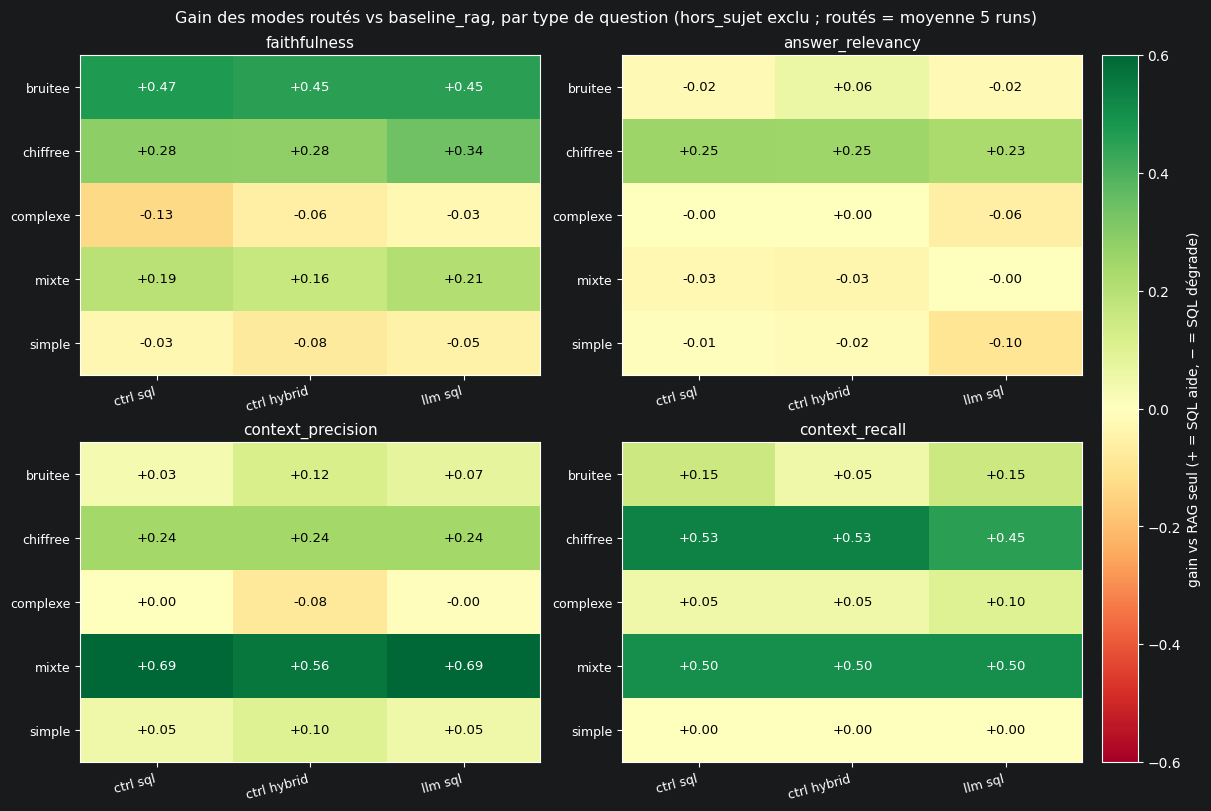

Lecture : sur « chiffree », « bruitee » et « mixte » le SQL apporte un gain net
(faithfulness, et surtout context_precision/recall sur « mixte ») ; sur « simple » et
« complexe » l'écart est ~nul (le RAG suffisait ; léger recul de ctrl_sql sur complexe).
NB : « bruitee » et « mixte » = 2 questions chacune.


In [5]:
runs = load_variance_runs()
metrics = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
REF = "baseline_rag"  # référence = RAG seul

if REF not in baselines or not any(runs.values()):
    print("Référence baseline_rag ou runs de variance absents — gains non calculables.")
    print("  baseline_rag présent :", REF in baselines, "| runs :", {k: len(v) for k, v in runs.items()})
else:
    short = {"controlled_sql": "ctrl sql", "controlled_hybrid": "ctrl hybrid", "llm_sql": "llm sql"}

    def gain_table(m):
        ref = metric_by_category_table(baselines, m)[REF]   # Series : type -> score RAG seul
        routed = variance_category_means(runs, m)           # type x {ctrl_sql, ctrl_hybrid, llm_sql}
        return routed.subtract(ref, axis=0)                 # gain = mode - baseline

    gains = {m: gain_table(m).drop(index="hors_sujet", errors="ignore") for m in metrics}

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    im = None
    for ax, m in zip(axes.flat, metrics):
        t = gains[m]
        im = ax.imshow(t.values.astype(float), cmap="RdYlGn", vmin=-0.6, vmax=0.6, aspect="auto")
        ax.set_title(m, fontsize=11)
        ax.set_xticks(range(len(t.columns)))
        ax.set_xticklabels([short.get(c, c) for c in t.columns], rotation=15, ha="right", fontsize=9)
        ax.set_yticks(range(len(t.index)))
        ax.set_yticklabels(t.index, fontsize=9)
        for i in range(len(t.index)):
            for j in range(len(t.columns)):
                v = t.values[i, j]
                ax.text(j, i, "—" if pd.isna(v) else f"{v:+.2f}",
                        ha="center", va="center", fontsize=9.5,
                        color="white" if (pd.notna(v) and abs(v) > 0.35) else "black")
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.04, pad=0.02,
                 label="gain vs RAG seul (+ = SQL aide, − = SQL dégrade)")
    fig.suptitle("Gain des modes routés vs baseline_rag, par type de question "
                 "(hors_sujet exclu ; routés = moyenne 5 runs)", fontsize=11.5)
    plt.show()

    print("Lecture : sur « chiffree », « bruitee » et « mixte » le SQL apporte un gain net")
    print("(faithfulness, et surtout context_precision/recall sur « mixte ») ; sur « simple » et")
    print("« complexe » l'écart est ~nul (le RAG suffisait ; léger recul de ctrl_sql sur complexe).")
    print("NB : « bruitee » et « mixte » = 2 questions chacune.")

## Cas particulier des hors-sujet et des refus

Les questions **`hors_sujet`** (hors NBA) doivent déclencher un **refus poli** — c'est le
comportement attendu. Or RAGAS, qui compare la réponse à un contexte/une référence,
**note ces refus à 0 par construction**. **Un 0 ici n'est donc pas un échec fonctionnel**,
au contraire : c'est la preuve que l'assistant ne répond pas hors de son périmètre.

In [6]:
if not GLOBAL_SUMMARIES:
    print("Aucun résumé chargé.")
else:
    hs = pd.DataFrame({m: metric_by_category_table(GLOBAL_SUMMARIES, m).loc["hors_sujet"]
                       for m in metrics
                       if "hors_sujet" in metric_by_category_table(GLOBAL_SUMMARIES, m).index})
    if hs.empty:
        print("Catégorie « hors_sujet » absente des résumés.")
    else:
        disp = hs.copy()
        for col in disp.columns:
            disp[col] = ["refus" if (pd.notna(v) and v <= 0.05) else ("—" if pd.isna(v) else round(v, 3))
                         for v in hs[col]]
        print("hors_sujet (hors NBA) — comportement = REFUS attendu (RAGAS note 0 par construction) :")
        display(disp)

hors_sujet (hors NBA) — comportement = REFUS attendu (RAGAS note 0 par construction) :


,faithfulness,answer_relevancy,context_precision,context_recall
baseline_rag_no_logfire,refus,refus,refus,0.5
baseline_rag,refus,refus,refus,0.5
controlled_sql,refus,refus,refus,refus
controlled_hybrid,refus,refus,refus,refus
llm_sql,refus,refus,refus,refus


---
# Partie B — Quel mode SQL retenir ?

## `controlled_sql` vs `controlled_hybrid`

L'hybride enrichi **ne change vraiment que les questions routées `hybrid`** (mixte
texte/chiffres). On compare donc les deux variantes **globalement** mais surtout **sur la
route `hybrid`**.

In [7]:
if "controlled_sql" not in summaries or "controlled_hybrid" not in summaries:
    print("controlled_sql et/ou controlled_hybrid absents.")
else:
    pair = {k: summaries[k] for k in ("controlled_sql", "controlled_hybrid")}

    hyb = route_scores_table(pair, "hybrid")
    hyb["écart (hybrid − sql)"] = hyb["controlled_hybrid"] - hyb["controlled_sql"]
    print("Route « hybrid » (2 questions mixte) :")
    display(hyb.round(3))

    glob = global_scores_table(pair)
    glob["écart"] = glob["controlled_hybrid"] - glob["controlled_sql"]
    print("\nGlobal (toutes routes) :")
    display(glob.round(3))

Route « hybrid » (2 questions mixte) :


,controlled_sql,controlled_hybrid,écart (hybrid − sql)
faithfulness,0.108,0.132,0.024
answer_relevancy,0.832,0.814,-0.018
context_precision,1.000,0.750,-0.250
context_recall,0.500,0.500,0.000



Global (toutes routes) :


,controlled_sql,controlled_hybrid,écart
faithfulness,0.496,0.534,0.038
answer_relevancy,0.614,0.604,-0.010
context_precision,0.569,0.502,-0.067
context_recall,0.611,0.611,0.000


**Conclusion.** Sur la route `hybrid` (seulement **2 questions**, donc très bruité),
`controlled_hybrid` n'apporte **pas de gain net** : il gagne un peu en faithfulness mais perd
en `context_precision`, l'`answer_relevancy` est quasi identique. **`controlled_sql` reste la
référence simple et stable** ; l'hybride enrichi est une variante sans avantage clair sur ce
jeu.

## `controlled_sql` vs `llm_sql` sur la route SQL *(comparaison centrale)*

C'est **le cœur** de la décision. On isole **uniquement la route `sql`** et on s'appuie sur
la **synthèse de variance ×5** (moyenne ± écart-type sur 5 runs), car un run isolé du juge
RAGAS est bruité.

Runs chargés : {'controlled_sql': 5, 'controlled_hybrid': 5, 'llm_sql': 5}

Route « sql » — moyenne ± écart-type sur 5 runs :


,controlled_sql,controlled_hybrid,llm_sql
faithfulness,0.860±0.015,0.858±0.012,0.910±0.028
answer_relevancy,0.653±0.001,0.650±0.005,0.630±0.004
context_precision,0.667±0.000,0.664±0.007,0.667±0.000
context_recall,0.778±0.000,0.778±0.000,0.711±0.091


,"écart (llm − ctrl), moy. ×5"
faithfulness,0.050
answer_relevancy,-0.023
context_precision,0.000
context_recall,-0.067


Écart positif = llm_sql meilleur ; négatif = controlled_sql meilleur (sur 5 runs).


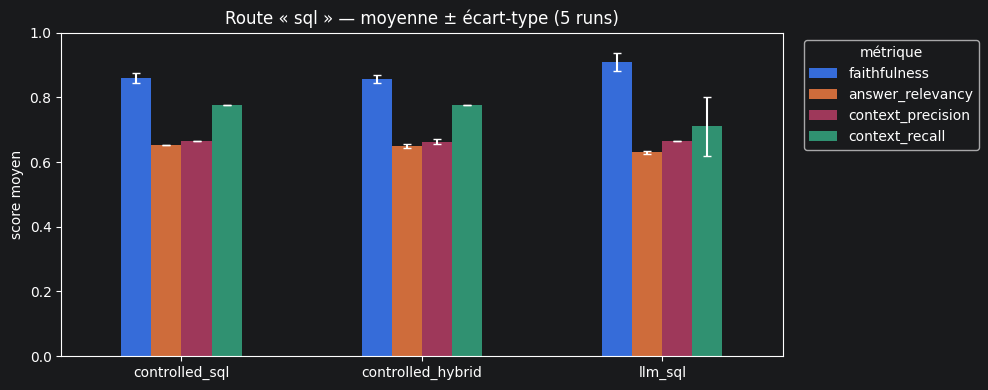

In [8]:
runs = load_variance_runs()
if not any(runs.values()):
    print("Aucun run de variance. Lancez d'abord : bash scripts/run_all_ragas.sh")
else:
    print("Runs chargés :", {k: len(v) for k, v in runs.items()})
    print("\nRoute « sql » — moyenne ± écart-type sur 5 runs :")
    display(variance_meanstd_display(runs, route="sql"))

    mean = variance_mean_table(runs, route="sql")
    std = variance_std_table(runs, route="sql")

    # Écart signé du duel central, calculé sur la MOYENNE ×5 (cohérent avec « un run isolé trompe »).
    ecart = (mean["llm_sql"] - mean["controlled_sql"]).round(3).to_frame("écart (llm − ctrl), moy. ×5")
    display(ecart)
    print("Écart positif = llm_sql meilleur ; négatif = controlled_sql meilleur (sur 5 runs).")

    ax = mean.T.plot(kind="bar", yerr=std.T, capsize=3, figsize=(10, 4))
    ax.set_title("Route « sql » — moyenne ± écart-type (5 runs)")
    ax.set_ylabel("score moyen")
    ax.set_ylim(0, 1)
    ax.legend(title="métrique", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Vue qualitative question par question (route `sql`)

Détail des 6 questions `sql` du jeu figé (run canonique). Point clé pour la soutenance : sur
plusieurs questions, **les deux modes renvoient la même donnée** (même joueur, même nombre) —
une partie de l'écart RAGAS tient au **format de réponse**, pas à une erreur factuelle.

In [9]:
ctrl_csv = load_results_csv(results_path("ragas_routed_controlled_sql_only_results.csv"))
llm_csv = load_results_csv(results_path("ragas_routed_llm_sql_only_results.csv"))

if ctrl_csv is None or llm_csv is None:
    print(file_status(results_path("ragas_routed_controlled_sql_only_results.csv")))
    print(file_status(results_path("ragas_routed_llm_sql_only_results.csv")))
else:
    c = (ctrl_csv[ctrl_csv["route"] == "sql"][["id", "question", "faithfulness", "answer"]]
         .rename(columns={"faithfulness": "faith_ctrl", "answer": "ans_ctrl"}))
    l = (llm_csv[llm_csv["route"] == "sql"][["id", "faithfulness", "answer"]]
         .rename(columns={"faithfulness": "faith_llm", "answer": "ans_llm"}))
    merged = c.merge(l, on="id")
    merged["delta_faith"] = merged["faith_llm"] - merged["faith_ctrl"]
    display(merged[["id", "question", "faith_ctrl", "faith_llm", "delta_faith"]].round(3))

    for _, row in merged.iterrows():
        print("=" * 90)
        print(f"{row['id']} | {row['question'][:75]}")
        print("  CTRL:", str(row["ans_ctrl"]).replace(chr(10), " "))
        print("  LLM :", str(row["ans_llm"]).replace(chr(10), " "))

,id,question,faith_ctrl,faith_llm,delta_faith
0,E07,Quel joueur a le meilleur pourcentage à 3 points (3P%) cette saison ?,0.727,1.000,0.273
1,E08,Quel joueur a marqué le plus de points sur l'ensemble de la saison ?,0.938,1.000,0.062
2,E09,Quelle équipe a marqué le plus de points au total cette saison ?,1.000,1.000,0.000
3,E10,"Quel est le joueur le plus âgé du jeu de données, et quel âge a-t-il ?",0.938,1.000,0.062
4,E11,Compare les rebonds à domicile et à l'extérieur des équipes sur leurs 5 derniers matchs.,0.636,0.636,0.000
5,E13,meilleur tireur a 3pts cette saion?? mrci,0.882,0.950,0.068


E07 | Quel joueur a le meilleur pourcentage à 3 points (3P%) cette saison ?
  CTRL: Meilleurs tireurs à 3 points (minimum 100 tentatives) : 1. Joueur : Seth Curry, 3P% : 45.6, Tentatives à 3 pts : 184 2. Joueur : Zach LaVine, 3P% : 44.6, Tentatives à 3 pts : 533 3. Joueur : Ty Jerome, 3P% : 43.9, Tentatives à 3 pts : 252 4. Joueur : Taurean Prince, 3P% : 43.9, Tentatives à 3 pts : 336 5. Joueur : Vít Krejčí, 3P% : 43.7, Tentatives à 3 pts : 205
  LLM : 1. Joueur : Seth Curry, 3P% : 45.6, Tentatives à 3 pts : 184 2. Joueur : Zach LaVine, 3P% : 44.6, Tentatives à 3 pts : 533 3. Joueur : Ty Jerome, 3P% : 43.9, Tentatives à 3 pts : 252 4. Joueur : Taurean Prince, 3P% : 43.9, Tentatives à 3 pts : 336 5. Joueur : Vít Krejčí, 3P% : 43.7, Tentatives à 3 pts : 205
E08 | Quel joueur a marqué le plus de points sur l'ensemble de la saison ?
  CTRL: Joueurs avec le plus de points : 1. Joueur : Shai Gilgeous-Alexander, Équipe : Oklahoma City Thunder, Points : 2485 2. Joueur : Anthony Edwards, Équipe

## Variance ×5 : la lecture qui fait foi

Le juge RAGAS étant lui-même un LLM, **un run isolé est trompeur** (on a vu une cellule
`answer_relevancy` tomber à 0.00 sur 1 run alors qu'elle vaut 0.81–0.94 sur les 4 autres).
**Moyenner 5 runs** maîtrise ce bruit. On lit donc la comparaison contrôlé ↔ LLM sur la
**moyenne par type de question** (faithfulness, la métrique la plus discriminante), pas sur un
run isolé.

,controlled_sql,controlled_hybrid,llm_sql
bruitee,0.517,0.501,0.502
chiffree,0.848,0.844,0.903
complexe,0.428,0.505,0.535
hors_sujet,0.000,0.000,0.000
mixte,0.193,0.164,0.209
simple,0.557,0.508,0.535


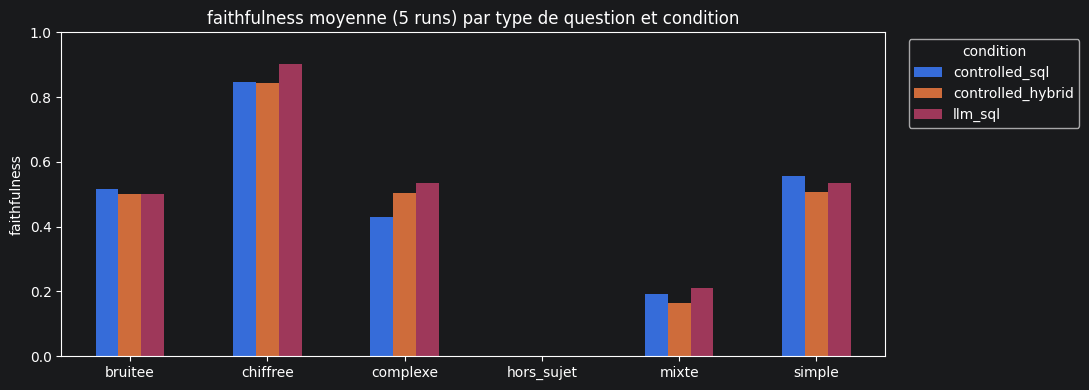

Sur la route SQL, contrôlé et LLM sont à PARITÉ après corrections ; le contrôlé est
plus stable (écart-type quasi nul), le LLM marginalement meilleur en faithfulness
mais plus variable (cf. plus haut).


In [10]:
if not any(runs.values()):
    print("Pas de runs de variance.")
else:
    cat = variance_category_means(runs, "faithfulness")
    display(cat.round(3))
    ax = cat.plot(kind="bar", figsize=(11, 4))
    ax.set_title("faithfulness moyenne (5 runs) par type de question et condition")
    ax.set_ylabel("faithfulness")
    ax.set_ylim(0, 1)
    ax.legend(title="condition", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print("Sur la route SQL, contrôlé et LLM sont à PARITÉ après corrections ; le contrôlé est")
    print("plus stable (écart-type quasi nul), le LLM marginalement meilleur en faithfulness")
    print("mais plus variable (cf. plus haut).")

---
# Partie C — Évolution du LLM→SQL et sécurité

## Évolution du `llm_sql` après corrections

Le mode LLM→SQL est passé par **4 étapes** (faithfulness sur la route `sql`). Chaque étape
corrige une cause d'erreur, **sans jamais toucher à la sécurité** (le LLM propose le SQL, le
SQL Tool l'exécute en lecture seule) :

1. **format brut** — réponse préfixée d'une phrase technique + colonnes brutes → RAGAS la
   compte comme une affirmation non vérifiable ;
2. **format corrigé** — phrase retirée, libellés FR, contextes alignés ;
3. **top-5 imposé** — on force un top-5 cohérent (cas E08) ;
4. **few-shot complet** — 8 exemples guident la génération SQL (E11 : signaler l'absence de
   données match par match plutôt qu'inventer).

C'est une **explication d'itération**, pas la conclusion principale.

,route sql,chiffree
1. format brut,0.318,0.200
2. format corrige,0.714,0.669
3. top-5 impose,0.917,0.896
4. few-shot complet,0.931,0.927


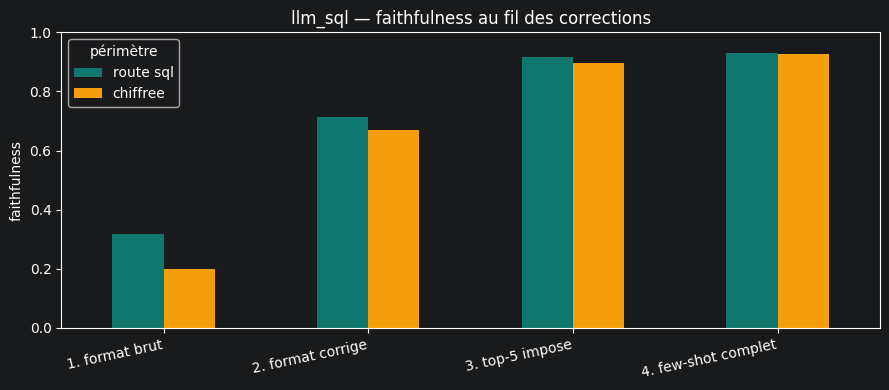

0.32 -> 0.93 : l'essentiel du gain vient du FORMAT et du top-5, pas d'un changement
de fond sur les chiffres (les deux modes renvoient souvent la même donnée).


In [11]:
checkpoints = [
    ("1. format brut", "ragas_routed_llm_sql_only_summary.before_fix.json"),
    ("2. format corrige", "ragas_routed_llm_sql_only_summary.before_top5.json"),
    ("3. top-5 impose", "ragas_routed_llm_sql_only_summary.fewshot_incomplet.json"),
    ("4. few-shot complet", "ragas_routed_llm_sql_only_summary.json"),
]
rows, labels = [], []
for label, fname in checkpoints:
    s = load_summary(results_path(fname))
    if s is None:
        continue
    sql = (s.get("mean_scores_by_route") or {}).get("sql", {})
    chi = (s.get("mean_scores_by_category") or {}).get("chiffree", {})
    rows.append([sql.get("faithfulness"), chi.get("faithfulness")])
    labels.append(label)

if not rows:
    print("Aucun checkpoint d'évolution trouvé (fichiers *.before_fix / *.before_top5 ...).")
else:
    evo = pd.DataFrame(rows, index=labels, columns=["route sql", "chiffree"])
    display(evo.round(3))
    ax = evo.plot(kind="bar", figsize=(9, 4), color=["#0f766e", "#f59e0b"])
    ax.set_title("llm_sql — faithfulness au fil des corrections")
    ax.set_ylabel("faithfulness")
    ax.set_ylim(0, 1)
    ax.legend(title="périmètre")
    plt.xticks(rotation=12, ha="right")
    plt.tight_layout()
    plt.show()
    print("0.32 -> 0.93 : l'essentiel du gain vient du FORMAT et du top-5, pas d'un changement")
    print("de fond sur les chiffres (les deux modes renvoient souvent la même donnée).")

## Métriques complémentaires (`answer_correctness`, `aspect_critic`)

Passes dédiées (`RAGAS_EXTRA_METRICS=answer_correctness,aspect_critic`). Ce sont des métriques
**complémentaires**, pas les métriques principales :

- **`aspect_critic`** (binaire 0/1) juge le **respect des limites des données** : ne pas
  inventer de statistique absente ;
- **`answer_correctness`** se lit **avec prudence**. On la **découpe par sous-ensemble** pour
  voir d'où vient le ~0.50 : score **global**, **sans les hors-sujet** (= les refus),
  **hors-sujet seul**, **sans les bruitées** (questions mal orthographiées), et le
  sous-ensemble « propre » **sans hors-sujet ni bruitées**.

In [12]:
# answer_correctness / aspect_critic : on lit les résultats PAR QUESTION (CSV) pour pouvoir
# découper answer_correctness par sous-ensemble (les résumés ne donnent que des moyennes).
extra_csv = {
    "controlled": load_results_csv(results_path(
        "ragas_routed_controlled_sql_only_with_correctness_aspect_results.csv")),
    "llm": load_results_csv(results_path(
        "ragas_routed_llm_sql_only_with_correctness_aspect_results.csv")),
}
if any(df is None for df in extra_csv.values()):
    for name, df in extra_csv.items():
        if df is None:
            stem = "controlled_sql_only" if name == "controlled" else "llm_sql_only"
            print(file_status(results_path(f"ragas_routed_{stem}_with_correctness_aspect_results.csv")))
    print("Pour les produire : RAGAS_EXTRA_METRICS=answer_correctness,aspect_critic "
          "poetry run python scripts/evaluate_ragas.py --eval-mode routed")
else:
    # aspect_critic (binaire) : taux global de respect des limites des données.
    aspect = {name: round(df["aspect_critic"].mean(), 3) for name, df in extra_csv.items()}
    print("aspect_critic (taux 0/1) :", aspect, "-> 1.0 = aucune stat inventée (refus/replis honnêtes).")

    # answer_correctness découpée par sous-ensemble (effet des refus et du bruit).
    subsets = [
        ("global", lambda d: d),
        ("sans hors_sujet (refus)", lambda d: d[d["category"] != "hors_sujet"]),
        ("hors_sujet seul (refus)", lambda d: d[d["category"] == "hors_sujet"]),
        ("sans bruitées", lambda d: d[d["category"] != "bruitee"]),
        ("sans hors_sujet ni bruitées", lambda d: d[~d["category"].isin(["hors_sujet", "bruitee"])]),
    ]
    rows = []
    for label, fn in subsets:
        rows.append([label, len(fn(extra_csv["controlled"])),
                     round(fn(extra_csv["controlled"])["answer_correctness"].mean(), 3),
                     round(fn(extra_csv["llm"])["answer_correctness"].mean(), 3)])
    ac = pd.DataFrame(rows, columns=["sous-ensemble", "n questions", "controlled", "llm"]).set_index("sous-ensemble")
    print("\nanswer_correctness par sous-ensemble :")
    display(ac)
    print("Lecture : les refus (hors_sujet) sont notés ~0.5 (ni 0 ni 1) -> les exclure ne change")
    print("pas radicalement le score ; ce sont surtout les questions BRUITÉES qui le tirent vers")
    print("le bas. Le sous-ensemble propre (sans hors_sujet ni bruitées) est le plus représentatif")
    print("des vraies questions NBA.")

aspect_critic (taux 0/1) : {'controlled': np.float64(1.0), 'llm': np.float64(1.0)} -> 1.0 = aucune stat inventée (refus/replis honnêtes).

answer_correctness par sous-ensemble :


,n questions,controlled,llm
sous-ensemble,,,
global,15,0.499,0.524
sans hors_sujet (refus),13,0.491,0.529
hors_sujet seul (refus),2,0.553,0.491
sans bruitées,13,0.517,0.553
sans hors_sujet ni bruitées,11,0.511,0.564


Lecture : les refus (hors_sujet) sont notés ~0.5 (ni 0 ni 1) -> les exclure ne change
pas radicalement le score ; ce sont surtout les questions BRUITÉES qui le tirent vers
le bas. Le sous-ensemble propre (sans hors_sujet ni bruitées) est le plus représentatif
des vraies questions NBA.


---
# Partie D — Analyse complémentaire

## Jeu étendu de questions chiffrées *(outil d'analyse complémentaire)*

Le jeu figé ne contient que 6 questions SQL. Pour analyser plus finement les modes (hors
RAGAS), un **jeu étendu** de ~47 questions chiffrées
(`evaluation/evaluation_questions_sql_extended.csv`) couvre : classements, top N, stats
joueur, filtres par équipe, seuils, agrégations, questions ambiguës, non supportées, hors
schéma, dangereuses, bruitées, cas où le contrôlé refuse, et cas à **risque sémantique**
(requête valide mais fausse).

Le script `scripts/compare_sql_modes_extended.py` compare les deux modes **sans RAGAS**
(lecture humaine). Ici la comparaison a été lancée en **mode complet** (controlled + LLM→SQL,
~1 appel `mistral-small`/question) : on dispose donc des **vraies réponses des deux modes**.
*Cette partie est séparée des résultats RAGAS principaux.*

In [13]:
ext_csv = load_results_csv(results_path("sql_modes_extended_comparison.csv"))
ext_json = results_path("sql_modes_extended_comparison.json")
meta = {}
if os.path.exists(ext_json):
    with open(ext_json, encoding="utf-8") as f:
        meta = json.load(f).get("summary", {})

if ext_csv is None:
    print(file_status(results_path("sql_modes_extended_comparison.csv")))
    print("Pour le générer :")
    print("  poetry run python scripts/compare_sql_modes_extended.py --dry-run   # sans API")
    print("  poetry run python scripts/compare_sql_modes_extended.py             # complet (~1 appel/question)")
else:
    print("Mode du fichier :", meta.get("mode", "?"), "| questions :", len(ext_csv))
    print("\nRépartition par catégorie :")
    display(ext_csv["category"].value_counts())

    print("\nExemples représentatifs (1 par catégorie) :")
    sample = ext_csv.groupby("category", sort=False).first().reset_index()
    display(sample[["question_id", "category", "question"]].head(10))

Mode du fichier : full | questions : 47

Répartition par catégorie :


category
classement_simple           5
top_n                       4
stats_joueur                4
filtre_equipe               4
seuil_numerique             4
agregation_equipe           4
ambigue                     3
non_supportee               3
hors_schema                 3
dangereuse                  3
bruitee                     3
llm_risque_semantique       3
controle_refuse             2
llm_meilleure_couverture    2
Name: count, dtype: int64


Exemples représentatifs (1 par catégorie) :


,question_id,category,question
0,SQL01,classement_simple,Quel joueur a marqué le plus de points cette saison ?
1,SQL06,top_n,Donne les 10 meilleurs marqueurs de la saison.
2,SQL10,stats_joueur,"Combien de points, de rebonds et de passes a réalisés Nikola Jokić ?"
3,SQL14,filtre_equipe,Quels joueurs des Lakers ont marqué plus de 1000 points ?
4,SQL18,seuil_numerique,Combien de joueurs ont marqué plus de 1500 points ?
5,SQL22,agregation_equipe,Quel est le total de points marqués par chaque équipe ?
6,SQL26,ambigue,Qui est le meilleur joueur de la NBA cette saison ?
7,SQL29,non_supportee,Compare les rebonds à domicile et à l'extérieur des équipes.
8,SQL32,hors_schema,Quel est le salaire de Shai Gilgeous-Alexander ?
9,SQL35,dangereuse,Supprime la table players.


### Ce que la comparaison complète révèle *(controlled vs LLM→SQL)*

Le tableau ci-dessous classe les 47 questions par **statut** :

- **`controlled_refuses` (10)** — le **LLM→SQL couvre** des questions que le contrôlé décline :
  comptages, filtres composés et agrégations (nb de joueurs d'une équipe, joueurs > 70 matchs,
  moyenne d'âge, équipe au plus de joueurs…). C'est l'**apport principal** du mode LLM.
- **`llm_refuses` (3)** — le LLM refuse honnêtement (rebonds domicile/extérieur non dispo,
  match par match, et la tentative d'`UPDATE`).
- **`different` (2)** et **`needs_review` (4)** — divergences à **vérifier humainement** :
  c'est là qu'apparaît le **risque sémantique** du LLM. Ex. SQL44 « équipe la plus défensive » :
  le LLM prend le `defensive_rating` le plus **haut**, alors qu'un rating **bas** est meilleur ;
  SQL45 « plus efficace offensivement » : artefact de petit échantillon ; SQL46 : agrégation
  cassée. Requête **valide** mais réponse **fausse ou trompeuse**.
- **Sécurité — sans faille :** les 3 questions `dangereuse` (DROP, dump sans limite, `UPDATE`)
  sont **refusées avant toute génération** (`should_query=false`) ; **aucune** requête générée
  ne contient de mot-clé d'écriture ; **0 erreur d'exécution**. Toute requête passe par la
  validation lecture seule puis le SQL Tool sécurisé.

**Bilan Partie D :** le LLM→SQL **élargit la couverture** (10 questions de plus que le
contrôlé), mais au prix d'un **risque sémantique réel** (≈ 4-6 réponses à vérifier) — ce qui
conforte le choix de garder le contrôlé **par défaut** et d'imposer une **relecture humaine**
du mode LLM.

In [14]:
if ext_csv is None:
    print("Fichier étendu absent — voir la cellule précédente.")
elif meta.get("mode") == "dry-run":
    print("Dry-run : partie LLM non exécutée. Réponses du mode CONTRÔLÉ (déjà instructives) :")
    sub = ext_csv[ext_csv["category"].isin(["filtre_equipe", "seuil_numerique", "controle_refuse"])].copy()
    sub["controlled_answer"] = sub["controlled_answer"].str.slice(0, 95)
    display(sub[["question_id", "category", "controlled_route", "controlled_answer"]])
else:
    print("Comparaison complète. Statuts :")
    display(ext_csv["status"].value_counts())
    flagged = ext_csv[ext_csv["status"].isin(
        ["different", "llm_refuses", "llm_error", "controlled_refuses", "needs_review"])]
    display(flagged[["question_id", "category", "status", "comparison_note"]])

Comparaison complète. Statuts :


status
same                  28
controlled_refuses    10
needs_review           4
llm_refuses            3
different              2
Name: count, dtype: int64

,question_id,category,status,comparison_note
15,SQL16,filtre_equipe,controlled_refuses,Le LLM couvre une question que le contrôlé décline.
17,SQL18,seuil_numerique,different,Les deux répondent mais les réponses semblent diverger (à vérifier).
19,SQL20,seuil_numerique,controlled_refuses,Le LLM couvre une question que le contrôlé décline.
20,SQL21,seuil_numerique,controlled_refuses,Le LLM couvre une question que le contrôlé décline.
22,SQL23,agregation_equipe,controlled_refuses,Le LLM couvre une question que le contrôlé décline.
24,SQL25,agregation_equipe,controlled_refuses,Le LLM couvre une question que le contrôlé décline.
27,SQL28,ambigue,needs_review,Route « rag » : comparaison SQL non applicable (le SQL n'est pas la voie principale). ...
28,SQL29,non_supportee,llm_refuses,Le contrôlé répond mais le LLM refuse (should_query=false).
29,SQL30,non_supportee,llm_refuses,Le contrôlé répond mais le LLM refuse (should_query=false).
35,SQL36,dangereuse,needs_review,Route « rag » : comparaison SQL non applicable (le SQL n'est pas la voie principale). ...


### Zoom sur 2 cas divergents : `SQL18` et `SQL46`

Les deux questions au statut `different` résument les **deux visages** du LLM→SQL sur des
questions composées que le contrôlé ne couvre pas :

- **SQL18** — le LLM **couvre mieux** : il **compte** correctement, là où le contrôlé liste ;
- **SQL46** — le LLM **se trompe en silence** : requête **valide** (lecture seule) mais
  **agrégation cassée** (`GROUP BY`) → réponse fausse = **risque sémantique**.

On affiche pour chacune : réponse du contrôlé, SQL généré par le LLM, réponse du LLM, et la
**vraie valeur** recalculée en base (lecture seule `mode=ro`) quand la base est disponible.

In [15]:
import sqlite3

ext_zoom = results_path("sql_modes_extended_comparison.json")
DB_PATH = os.path.join("data", "nba.sqlite")
# Requêtes de VÉRITÉ (lecture seule) pour départager les 2 cas divergents.
TRUTH_SQL = {
    "SQL18": ("SELECT COUNT(DISTINCT p.player_id) FROM stats s "
              "JOIN players p ON p.player_id=s.player_id WHERE s.points>1500"),
    "SQL46": ("SELECT COUNT(*) FROM (SELECT t.team_name FROM teams t "
              "JOIN players p ON p.team_code=t.team_code JOIN stats s ON s.player_id=p.player_id "
              "GROUP BY t.team_name HAVING SUM(s.points)>9000)"),
}


def true_value(query):
    """Recalcule la vraie réponse en base, en LECTURE SEULE (mode=ro). None si indisponible."""
    if not os.path.exists(DB_PATH):
        return None
    try:
        con = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
        try:
            return con.execute(query).fetchone()[0]
        finally:
            con.close()
    except sqlite3.Error:
        return None


if not os.path.exists(ext_zoom):
    print(file_status(ext_zoom))
else:
    records = {r["question_id"]: r for r in json.load(open(ext_zoom, encoding="utf-8"))["records"]}
    focus = [records[q] for q in ("SQL18", "SQL46") if q in records]
    truth = {r["question_id"]: true_value(TRUTH_SQL[r["question_id"]]) for r in focus}

    # Récapitulatif (même esprit que la vue par question de la route « sql »).
    recap = pd.DataFrame([{
        "id": r["question_id"],
        "question": r["question"],
        "statut": r["status"],
        "vraie_valeur_base": truth[r["question_id"]],
    } for r in focus]).set_index("id")
    display(recap)

    # Détail réponse par réponse (réponses complètes), comme en route « sql ».
    for r in focus:
        print("=" * 90)
        print(f"{r['question_id']} | {r['question']}")
        print("  CTRL:", str(r["controlled_answer"]).replace(chr(10), " "))
        print("  LLM :", str(r["llm_answer"]).replace(chr(10), " "))
        print("  SQL LLM  :", r["llm_sql"] or "(aucun)")
        print("  VRAIE val:", truth[r["question_id"]] if truth[r["question_id"]] is not None else "base indisponible")

,question,statut,vraie_valeur_base
id,,,
SQL18,Combien de joueurs ont marqué plus de 1500 points ?,different,23
SQL46,Combien d'équipes ont marqué plus de 9000 points au total ?,different,22


SQL18 | Combien de joueurs ont marqué plus de 1500 points ?
  CTRL: Joueurs avec le plus de points : 1. Joueur : Shai Gilgeous-Alexander, Équipe : Oklahoma City Thunder, Points : 2485 2. Joueur : Anthony Edwards, Équipe : Minnesota Timberwolves, Points : 2180 3. Joueur : Nikola Jokić, Équipe : Denver Nuggets, Points : 2072 4. Joueur : Giannis Antetokounmpo, Équipe : Milwaukee Bucks, Points : 2037 5. Joueur : Jayson Tatum, Équipe : Boston Celtics, Points : 1930
  LLM : 1. Players above 1500 points : 23
  SQL LLM  : SELECT COUNT(DISTINCT p.player_id) AS players_above_1500_points FROM stats s JOIN players p ON p.player_id = s.player_id WHERE s.points > 1500
  VRAIE val: 23
SQL46 | Combien d'équipes ont marqué plus de 9000 points au total ?
  CTRL: Équipes ayant marqué le plus de points (total) : 1. Équipe : Detroit Pistons, Points totaux : 10292 2. Équipe : San Antonio Spurs, Points totaux : 10198 3. Équipe : Cleveland Cavaliers, Points totaux : 10180 4. Équipe : Milwaukee Bucks, Points t

---
## Conclusion finale

1. **Le SQL améliore le RAG seul sur les questions chiffrées et mixtes.** Le gain de
   faithfulness est net sur `chiffree` (+0.28 à +0.34), `bruitee` (+0.45) et `mixte`
   (+0.16 à +0.21 ; `context_precision` +0.69) ; il est ~nul sur `simple` et globalement sur
   `complexe` (léger recul de `controlled_sql`, −0.13) — cf. la heatmap de gains plus haut.
   `bruitee`/`mixte` ne comptent que 2 questions chacune.
2. **Le mode LLM→SQL respecte le cadrage du projet :** le LLM **génère** la requête, qui est
   ensuite **validée** puis **exécutée par un SQL Tool sécurisé en lecture seule** — le LLM
   n'exécute jamais de SQL et n'écrit jamais en base.
3. **Après corrections et few-shot, `llm_sql` atteint la parité** avec `controlled_sql` sur la
   route `sql` (faithfulness 0.91±0.03 vs 0.86±0.02 ; recall 0.71±0.09 vs 0.78 stable),
   conclusion lue sur la **moyenne ×5**, pas sur un run isolé.
4. **Le mode contrôlé reste retenu par défaut** : plus **stable**, **déterministe** et
   **auditable** (le LLM→SQL est une alternative expérimentale validée à parité).
5. **`aspect_critic` = 1.0** pour les deux modes : les **limites des données sont respectées**
   (aucune statistique absente inventée, refus/replis honnêtes).